In [8]:
import numpy as np
from hmm_module import (create_transition_matrix, 
                        p_z1_given_c, 
                        simulate_c, 
                        simulate_z, 
                        simulate_x, 
                        simulate_hmm,
                        plot_single,
                        plot_freq,
                        plot_all,
                        plot_mean,
                        make_datasets,
                        emission_matrix,
                        forward_C,
                        backward_C,
                        compute_smoothed_prob,
                        posterior_Z,
                        hmm_pipeline,
                        plot_heatmap_z
                        )

In [9]:
# suggested values
alpha_val = 0.9
beta_val = 0.2
small_gamma_val = 0.1
lambda_0 = 1
lambda_1 = 5

n = 10
big_T = 100

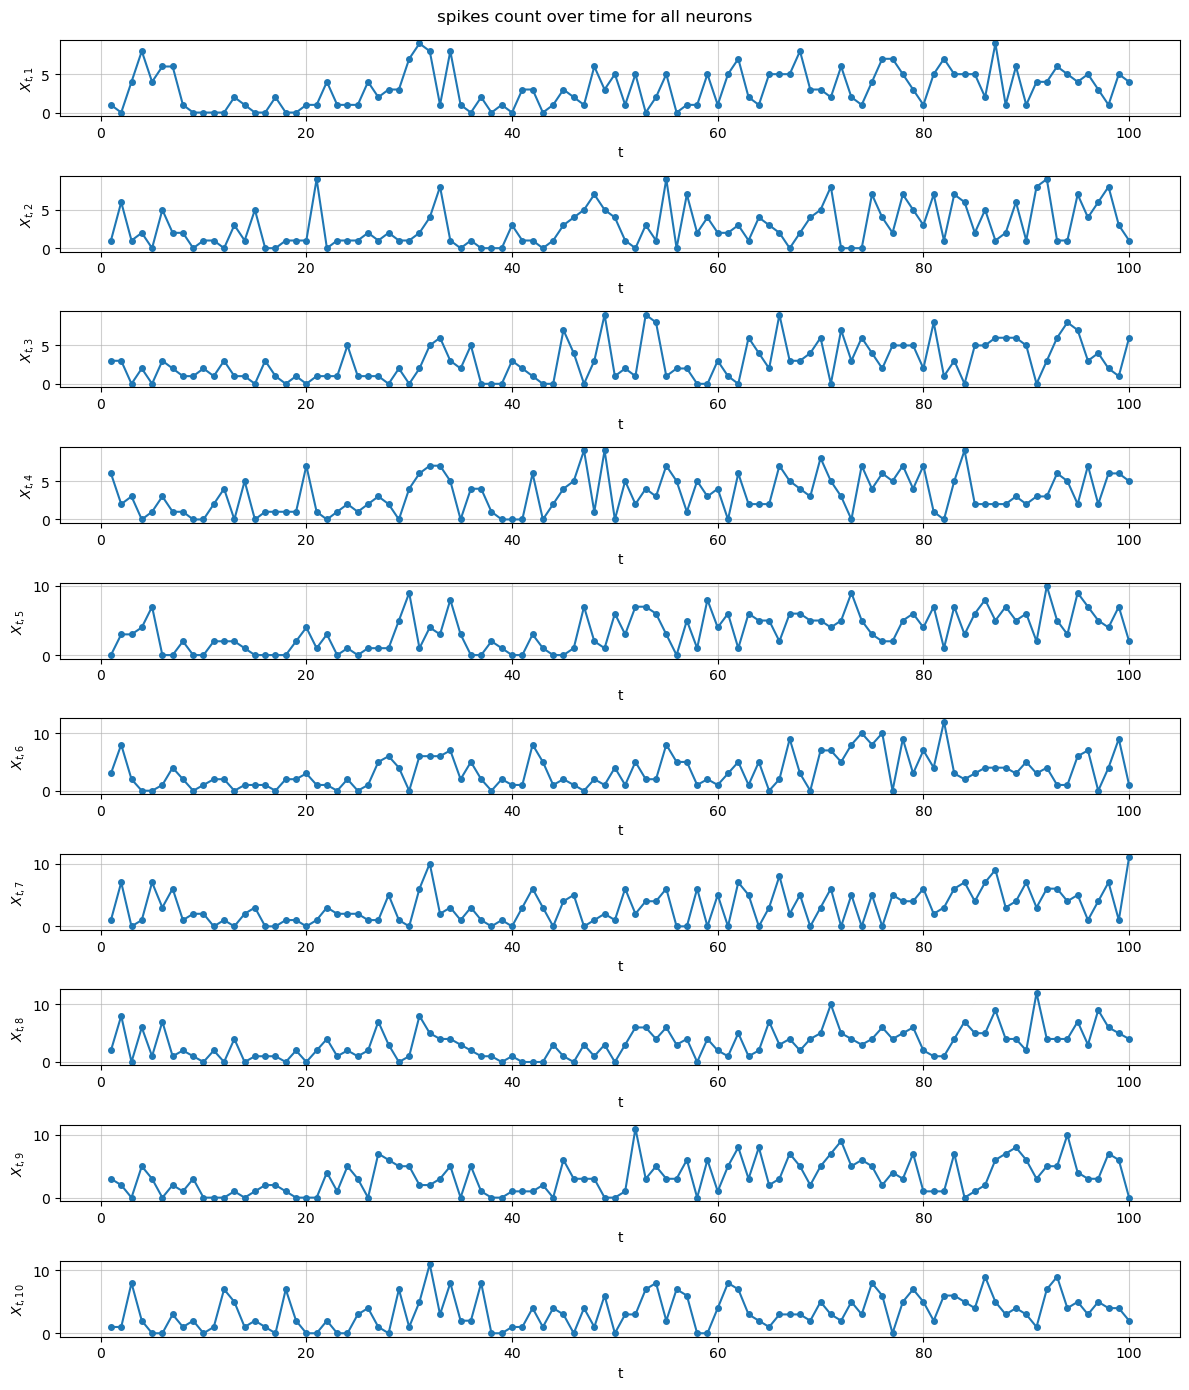

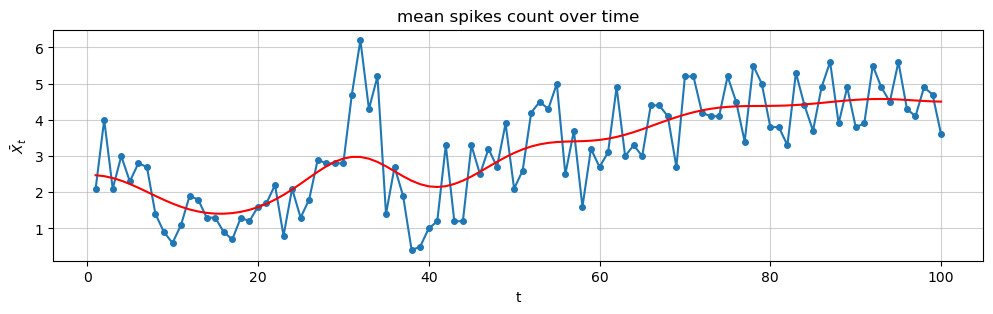

In [10]:
C, Z, X = simulate_hmm(big_T, n, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1)
plot_all(X)
plot_mean(X)

In [11]:
# first we generate the some dataset
x_features_data = []
y_labels_data = []

X_full_data = []
C_full_data = []
Z_full_data = []

t_indexes = [9, 19, 29, 39, 49, 59, 69, 79, 89, 99]
for t_idx in t_indexes:
    # with seed = 123 + t_idx, we get a different dataset for each t_index
    x_features, y_labels, X_full, C_full, Z_full = make_datasets(500, t_idx, big_T, n, alpha_val, beta_val,
                                                                 small_gamma_val, lambda_0, lambda_1, seed=123 + t_idx)
    x_features_data.append(x_features)
    y_labels_data.append(y_labels)
    X_full_data.append(X_full)
    C_full_data.append(C_full)
    Z_full_data.append(Z_full)
print(x_features_data[0].shape) # feature shape: (M, n)
print(y_labels_data[0].shape)   # labels shape: (M,)
print("class counts:", np.bincount(y_labels_data[0], minlength=3))

(500, 10)
(500,)
class counts: [163 149 188]


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train_data = []
x_test_data = []
y_train_data = []
y_test_data = []

X_full_train_data = []
X_full_test_data = []
C_full_train_data = []
C_full_test_data = []
Z_full_train_data = []
Z_full_test_data = []


for i in range(len(t_indexes)):
    x_train, x_test, y_train, y_test, X_full_train, X_full_test, C_full_train, C_full_test, Z_full_train, Z_full_test = train_test_split(
        x_features_data[i], y_labels_data[i], X_full_data[i], C_full_data[i], Z_full_data[i], test_size=0.2, random_state=123)

    x_train_data.append(x_train)
    x_test_data.append(x_test)
    y_train_data.append(y_train)
    y_test_data.append(y_test)

    X_full_train_data.append(X_full_train)
    X_full_test_data.append(X_full_test)
    C_full_train_data.append(C_full_train)
    C_full_test_data.append(C_full_test)
    Z_full_train_data.append(Z_full_train)
    Z_full_test_data.append(Z_full_test)

models = []
train_errors = []
test_errors = []

for i in range(len(t_indexes)):
    model = LogisticRegression(max_iter=5000, random_state=123)
    model.fit(x_train_data[i], y_train_data[i])
    
    train_errors.append(1 - model.score(x_train_data[i], y_train_data[i]))
    test_errors.append(1 - model.score(x_test_data[i], y_test_data[i]))
    models.append(model)

for i in range(len(t_indexes)):
    print(f"t={t_indexes[i]+1}: train_error={train_errors[i]:.6f}, test_error={test_errors[i]:.6f}")

t=10: train_error=0.200000, test_error=0.190000
t=20: train_error=0.175000, test_error=0.220000
t=30: train_error=0.180000, test_error=0.180000
t=40: train_error=0.175000, test_error=0.180000
t=50: train_error=0.157500, test_error=0.210000
t=60: train_error=0.182500, test_error=0.170000
t=70: train_error=0.160000, test_error=0.180000
t=80: train_error=0.175000, test_error=0.180000
t=90: train_error=0.165000, test_error=0.200000
t=100: train_error=0.182500, test_error=0.090000


In [13]:
C_true, Z_true, X_sim = simulate_hmm(big_T, n, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1, seed=123)

res_sim = hmm_pipeline(X_sim, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1)

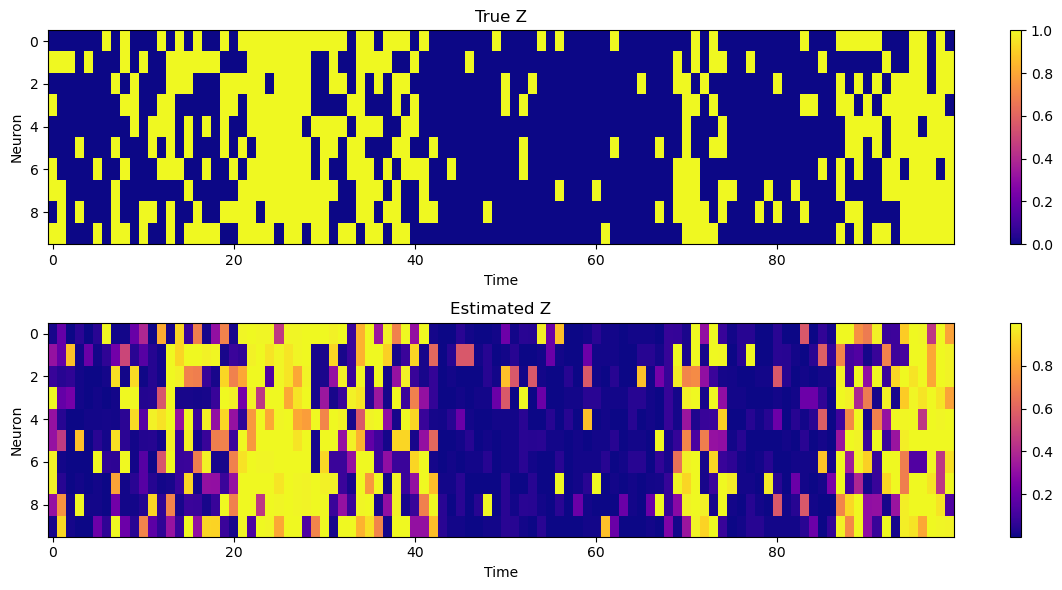

In [14]:
plot_heatmap_z(Z_true, res_sim["qZ"])